# Exploring GPM IMERG early and late producst, ERA5 and SEVIRI data

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

## Download data

In [2]:
!curl -L -o gpm_imerg_early.nc "https://drive.usercontent.google.com/download?id=1qH2-FyDtz8h4Ka19LCvjxJy1Xk4ALWN9&confirm=yes"
!curl -L -o gpm_imerg_final.nc "https://drive.usercontent.google.com/download?id=1dZa45SEh-h3-EobPP0Ef6f-GyQnsa7mS&confirm=yes"
!curl -L -o era5.nc "https://drive.usercontent.google.com/download?id=1dBRrvUQL3srlLiyX9LunviTv-4zaDpte&confirm=yes"
!curl -L -o seviri_openmrg2.nc "https://drive.usercontent.google.com/download?id=1aeSovV7K-H5i0sHmpdqFYHsX0zgHmRXC&confirm=yes"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 21.7M  100 21.7M    0     0  4089k      0  0:00:05  0:00:05 --:--:-- 5157k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 21.7M  100 21.7M    0     0  4439k      0  0:00:05  0:00:05 --:--:-- 5619k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7029k  100 7029k    0     0  2366k      0  0:00:02  0:00:02 --:--:-- 2365k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  308M  100  308M    0     0  6769k      0  0:00:46  0:00:46 --:--:-- 6945k


In [3]:
ds_gpm_imerg_early = xr.open_dataset("gpm_imerg_early.nc")
ds_gpm_imerg_final = xr.open_dataset("gpm_imerg_final.nc")
ds_era5 = xr.open_dataset("era5.nc")
ds_seviri = xr.open_dataset('seviri_openmrg2.nc')

In [4]:
ds_era5

<xarray.Dataset> Size: 11MB
Dimensions:          (time: 2208, lat: 12, lon: 18)
Coordinates:
  * time             (time) datetime64[ns] 18kB 2015-06-01 ... 2015-08-31T23:...
  * lat              (lat) float64 96B 59.67 59.42 59.17 ... 57.42 57.17 56.92
  * lon              (lon) float64 144B 10.02 10.27 10.52 ... 13.77 14.02 14.27
Data variables:
    u10              (time, lat, lon) float32 2MB ...
    v10              (time, lat, lon) float32 2MB ...
    d2m              (time, lat, lon) float32 2MB ...
    t2m              (time, lat, lon) float32 2MB ...
    sp               (time, lat, lon) float32 2MB ...
    rainfall_amount  (time, lat, lon) float32 2MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-05-12T10:03 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
# TODO: Update the NetCDF file so that we do not have to do this here
ds_seviri = (
    ds_seviri.rename_vars({'time': 'foo'})
    .rename_dims({'t': 'time'})
    .rename_vars({'foo': 'time'})
)

## Plot GPM, ERA5 and SEVIRI into one nice figure

In [8]:
import cartopy.crs as ccrs

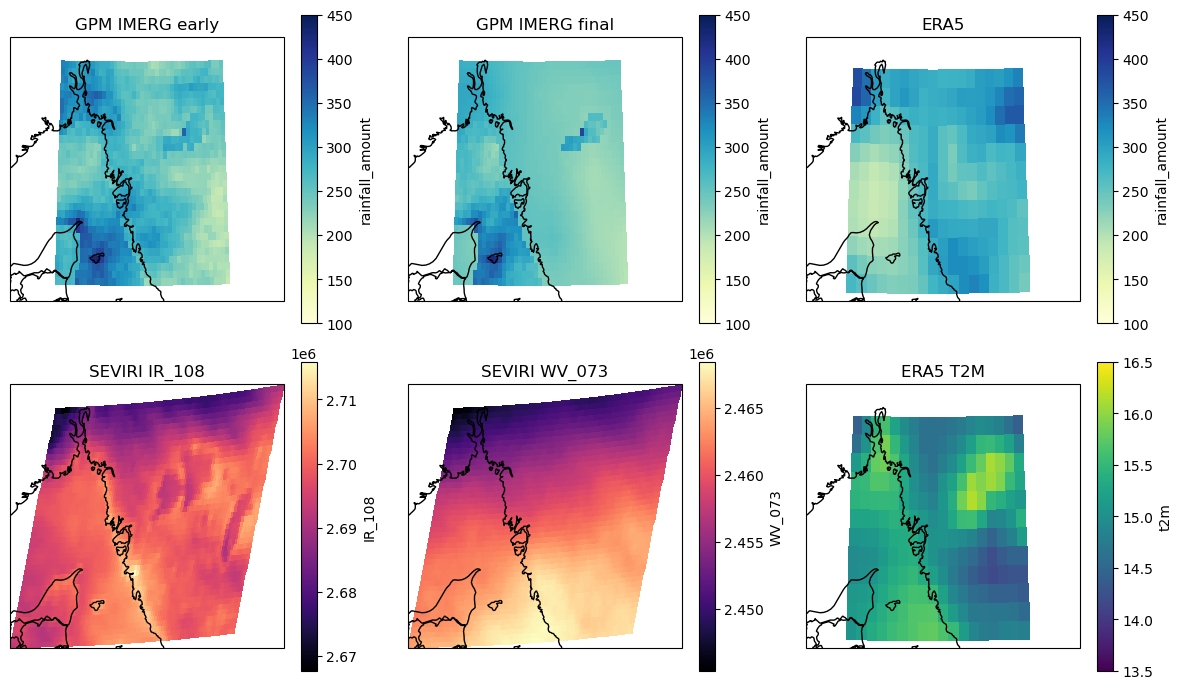

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(12,7), sharey=True, sharex=True, subplot_kw=dict(projection=ccrs.Orthographic(12, 59)))

(ds_gpm_imerg_early.rainfall_amount.sum(dim='time')).plot(ax=axs[0,0],x='lon',y='lat',vmin=100,vmax=450,cmap='YlGnBu', transform=ccrs.PlateCarree())
axs[0,0].set_title("GPM IMERG early")
(ds_gpm_imerg_final.rainfall_amount.sum(dim='time')).plot(ax=axs[0,1],x='lon',y='lat',vmin=100,vmax=450,cmap='YlGnBu', transform=ccrs.PlateCarree())
axs[0,1].set_title("GPM IMERG final")
(ds_era5.rainfall_amount.sum(dim='time')).plot(ax=axs[0,2],vmin=100,vmax=450,cmap='YlGnBu', transform=ccrs.PlateCarree())
axs[0,2].set_title("ERA5")

ds_seviri['IR_108'].mean(dim=['time']).plot(ax=axs[1, 0], x='lon', y='lat', cmap='magma', transform=ccrs.PlateCarree())
axs[1, 0].set_title("SEVIRI IR_108")
ds_seviri['WV_073'].mean(dim=['time']).plot(ax=axs[1, 1], x='lon', y='lat', cmap='magma', transform=ccrs.PlateCarree())
axs[1, 1].set_title("SEVIRI WV_073")
(ds_era5.t2m.mean(dim='time') - 273.15).plot(ax=axs[1, 2], x='lon', y='lat', cmap='viridis', vmin=13.5, vmax=16.5, transform=ccrs.PlateCarree())
axs[1, 2].set_title("ERA5 T2M")

for ax in axs.flatten():
    ax.coastlines() 

plt.tight_layout()

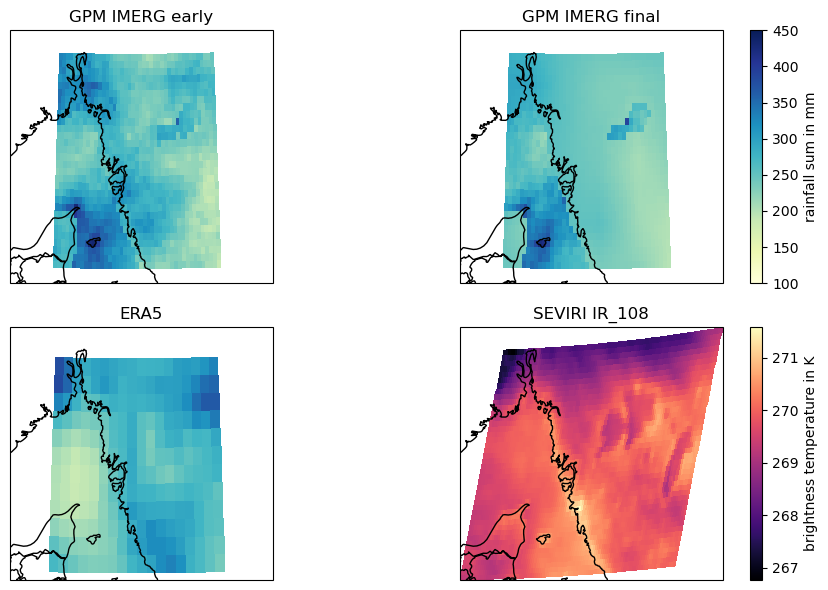

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(10,6), sharey=True, sharex=True, subplot_kw=dict(projection=ccrs.Orthographic(12, 59)))

(ds_gpm_imerg_early.rainfall_amount.sum(dim='time')).plot(ax=axs[0,0],x='lon',y='lat',vmin=100,vmax=450,cmap='YlGnBu', add_colorbar=False, transform=ccrs.PlateCarree())
axs[0,0].set_title("GPM IMERG early")
(ds_gpm_imerg_final.rainfall_amount.sum(dim='time')).plot(ax=axs[0,1],x='lon',y='lat',vmin=100,vmax=450,cmap='YlGnBu', cbar_kwargs={'label': 'rainfall sum in mm'}, transform=ccrs.PlateCarree())
axs[0,1].set_title("GPM IMERG final")

(ds_era5.rainfall_amount.sum(dim='time')).plot(ax=axs[1, 0],vmin=100,vmax=450,cmap='YlGnBu', add_colorbar=False, transform=ccrs.PlateCarree())
axs[1, 0].set_title("ERA5")
(ds_seviri['IR_108']/1e4).mean(dim=['time']).plot(ax=axs[1, 1], x='lon', y='lat', cmap='magma', cbar_kwargs={'label': 'brightness temperature in K'}, transform=ccrs.PlateCarree())
axs[1, 1].set_title("SEVIRI IR_108")


for ax in axs.flatten():
    ax.coastlines() 

plt.tight_layout()

## More GPM and ERA5 plots

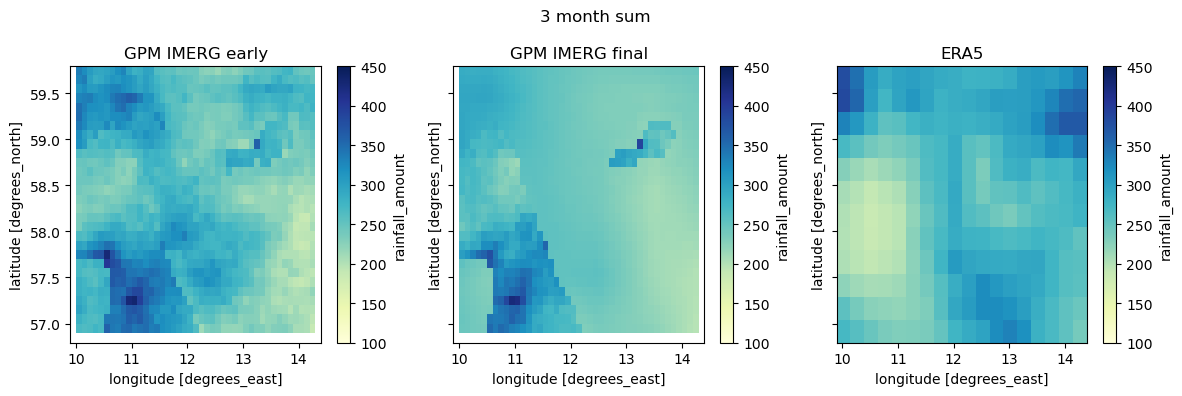

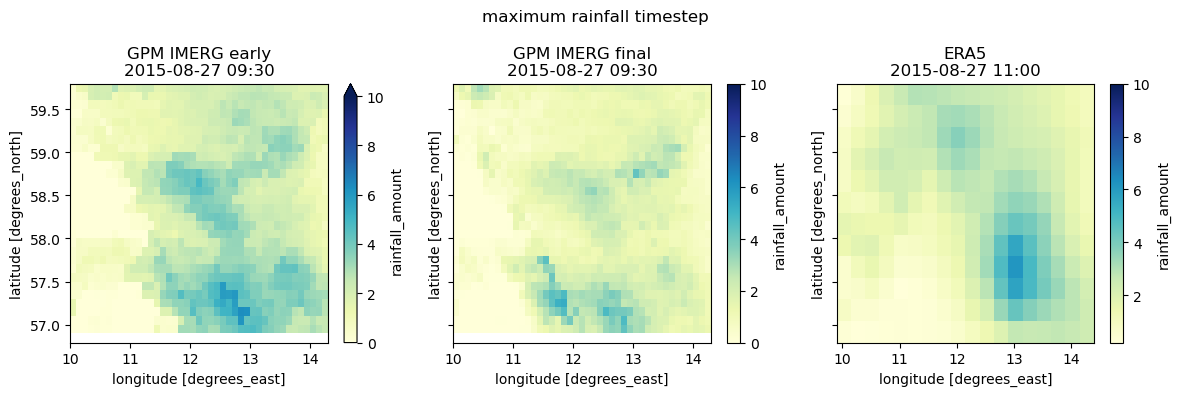

In [8]:
# three month sum
fig,ax=plt.subplots(1,3,figsize=(12,4),sharey=True,sharex=True)
(ds_gpm_imerg_early.rainfall_amount.sum(dim='time')).plot(ax=ax[0],x='lon',y='lat',vmin=100,vmax=450,cmap='YlGnBu')
(ds_gpm_imerg_final.rainfall_amount.sum(dim='time')).plot(ax=ax[1],x='lon',y='lat',vmin=100,vmax=450,cmap='YlGnBu')
(ds_era5.rainfall_amount.sum(dim='time')).plot(ax=ax[2],vmin=100,vmax=450,cmap='YlGnBu')
ax[0].set_title("GPM IMERG early")
ax[1].set_title("GPM IMERG final")
ax[2].set_title("ERA5")
fig.suptitle('3 month sum')
plt.tight_layout()

# timestep with max rainfall
early_max_ts = ds_gpm_imerg_early.rainfall_amount.sum(dim=['lon','lat']).idxmax()
final_max_ts = ds_gpm_imerg_final.rainfall_amount.sum(dim=['lon','lat']).idxmax()
era5_max_ts = ds_era5.rainfall_amount.sum(dim=['lon','lat']).idxmax()


fig,ax=plt.subplots(1,3,figsize=(12,4),sharey=True)
(ds_gpm_imerg_early.rainfall_amount.sel(time=early_max_ts)).plot(ax=ax[0],x='lon',y='lat',vmax=10,cmap='YlGnBu')
(ds_gpm_imerg_final.rainfall_amount.sel(time=final_max_ts)).plot(ax=ax[1],x='lon',y='lat',vmax=10,cmap='YlGnBu')
(ds_era5.rainfall_amount).sel(time=era5_max_ts).plot(ax=ax[2],vmax=10,cmap='YlGnBu')
ax[0].set_title("GPM IMERG early\n"+str(early_max_ts.values.astype('M8[ms]').item().strftime('%Y-%m-%d %H:%M')))
ax[1].set_title("GPM IMERG final\n"+str(final_max_ts.values.astype('M8[ms]').item().strftime('%Y-%m-%d %H:%M')))
ax[2].set_title("ERA5\n"+str(era5_max_ts.values.astype('M8[ms]').item().strftime('%Y-%m-%d %H:%M')))
fig.suptitle('maximum rainfall timestep')
plt.tight_layout();

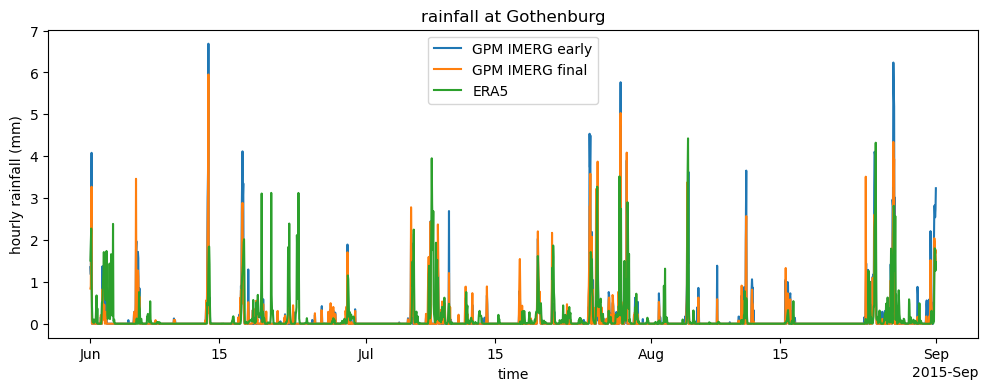

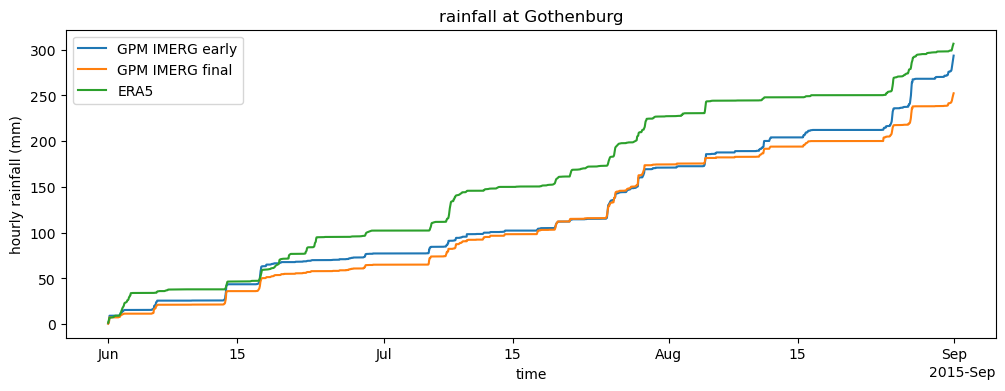

In [9]:
ds_gpm_imerg_early.sel(lon=11.9675,lat=57.7075,method='nearest').rainfall_amount.resample(time='1h').sum().plot(label='GPM IMERG early',figsize=(12,4))
ds_gpm_imerg_final.sel(lon=11.9675,lat=57.7075,method='nearest').rainfall_amount.resample(time='1h').sum().plot(label='GPM IMERG final')
(ds_era5.sel(lon=11.9675,lat=57.7075,method='nearest').rainfall_amount).plot(label='ERA5')
plt.legend()
plt.title('rainfall at Gothenburg')
plt.ylabel("hourly rainfall (mm)")

ds_gpm_imerg_early.sel(lon=11.9675,lat=57.7075,method='nearest').rainfall_amount.cumsum().plot(label='GPM IMERG early',figsize=(12,4))
ds_gpm_imerg_final.sel(lon=11.9675,lat=57.7075,method='nearest').rainfall_amount.cumsum().plot(label='GPM IMERG final')
(ds_era5.sel(lon=11.9675,lat=57.7075,method='nearest').rainfall_amount).cumsum().plot(label='ERA5')
plt.legend()
plt.title('rainfall at Gothenburg')
plt.ylabel("hourly rainfall (mm)");

## More SEVIRI plots

In [10]:
%%time
ds_seviri = ds_seviri.load()

CPU times: user 2.9 s, sys: 355 ms, total: 3.26 s
Wall time: 3.29 s


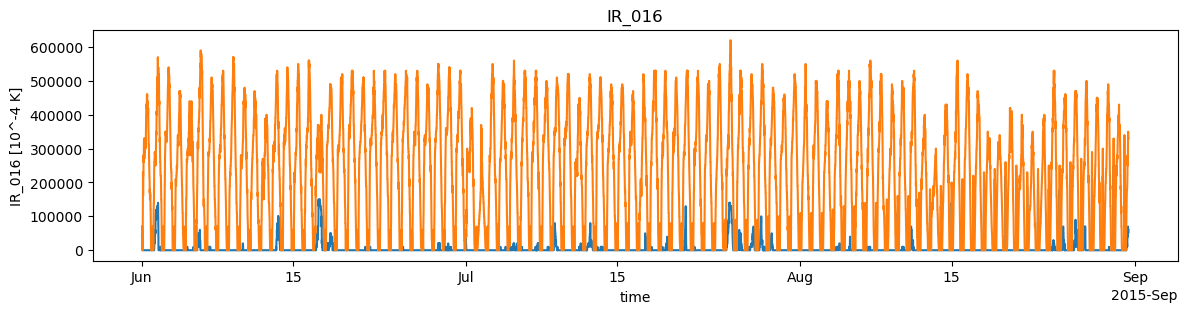

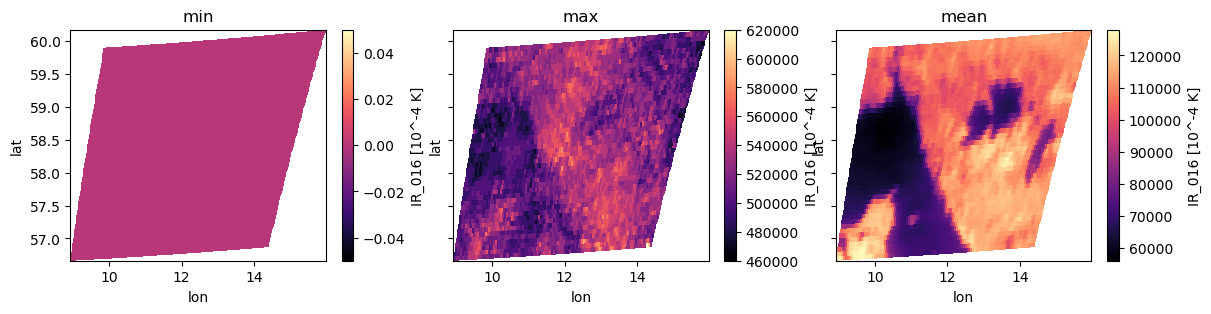

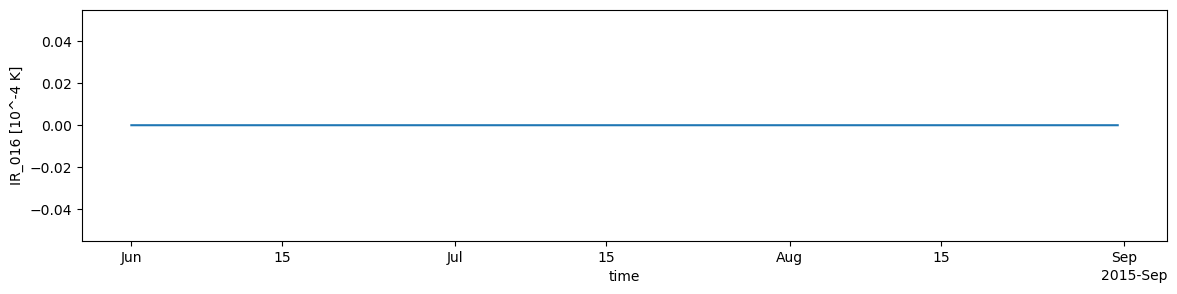

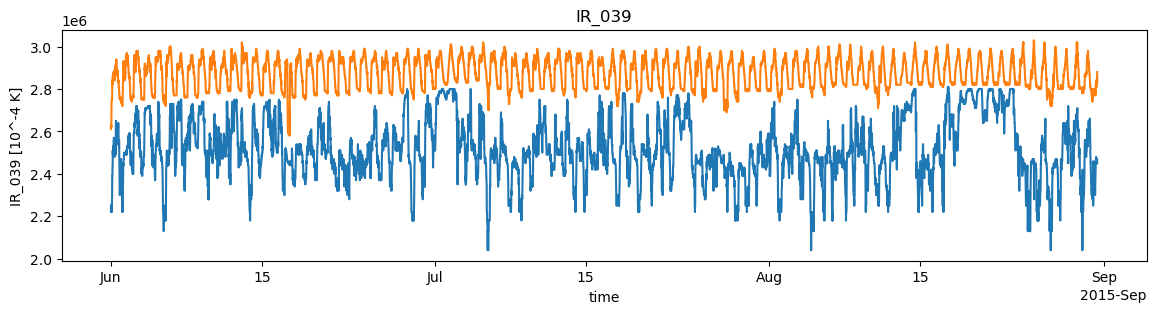

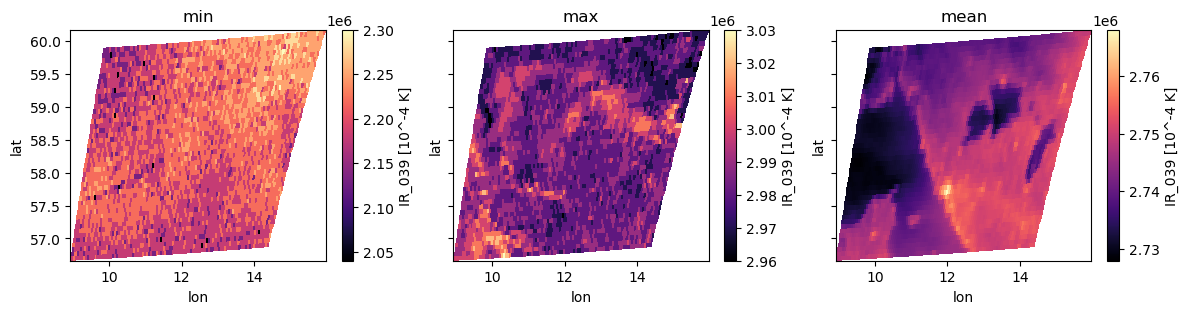

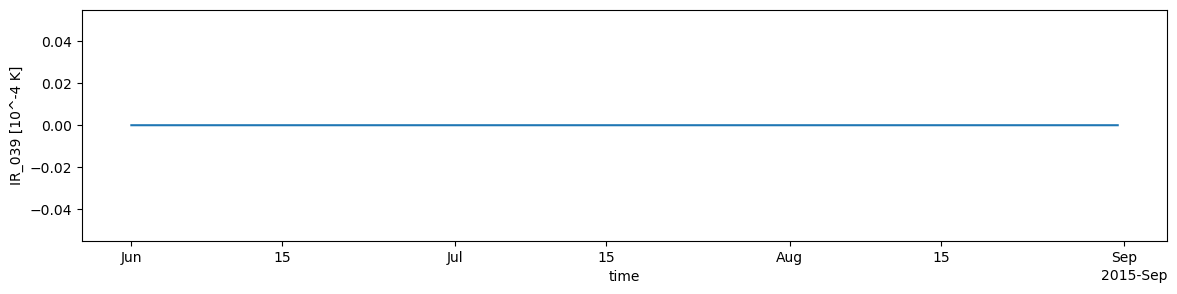

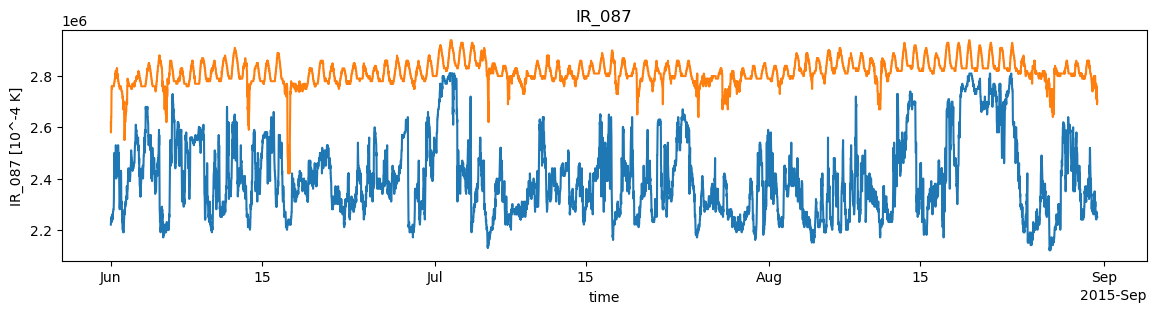

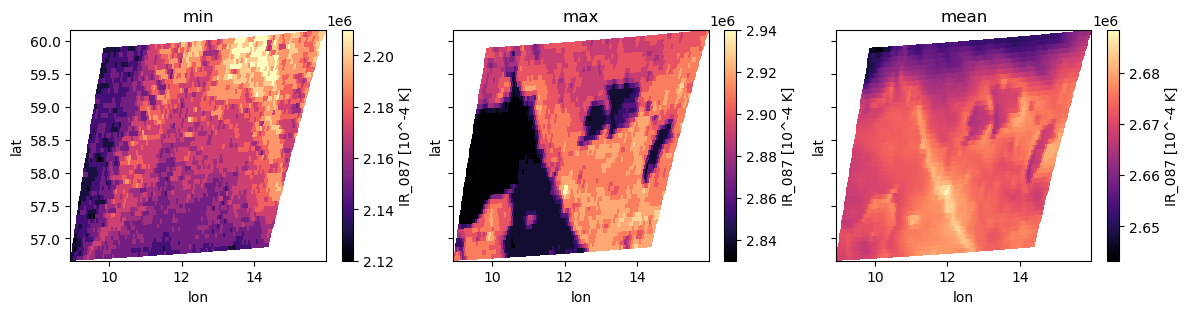

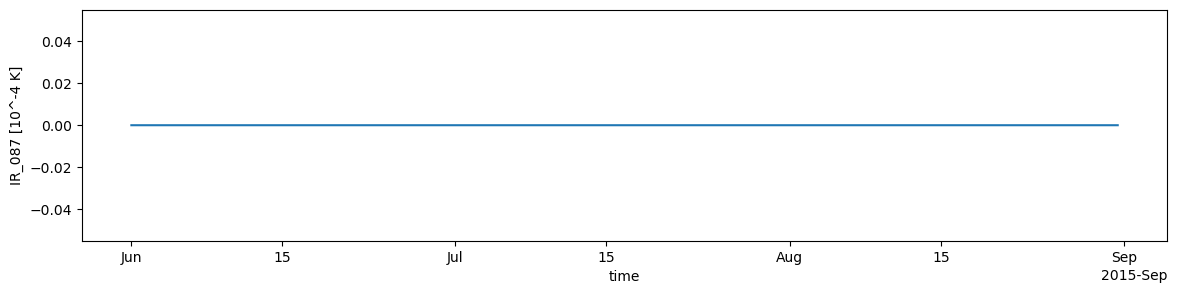

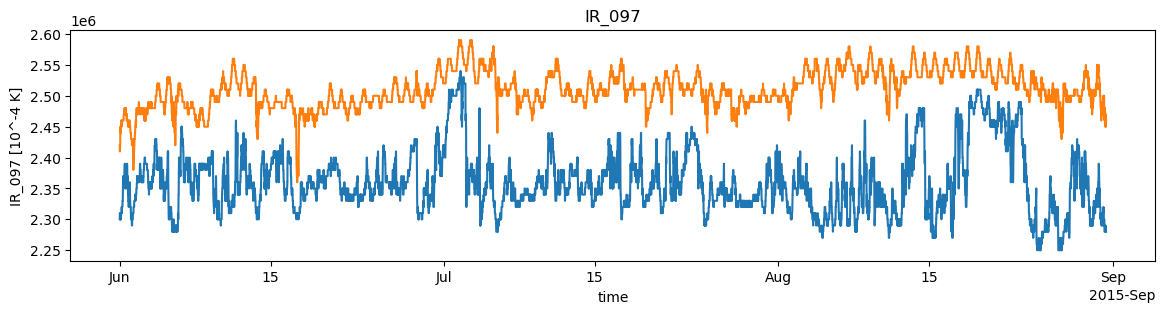

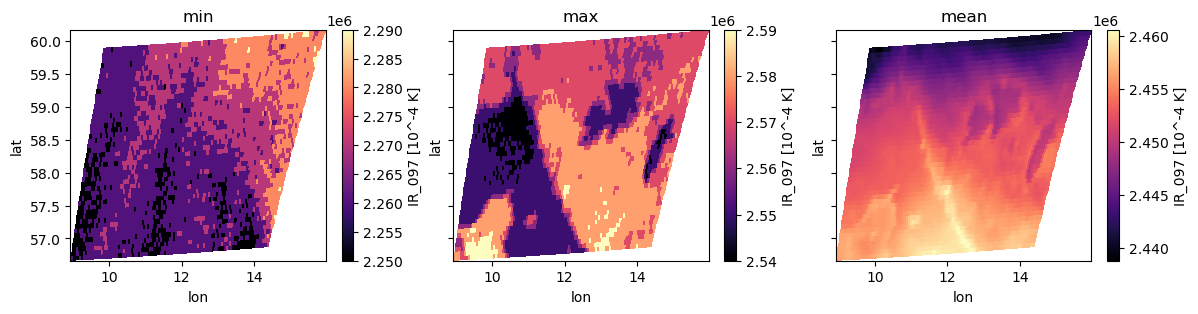

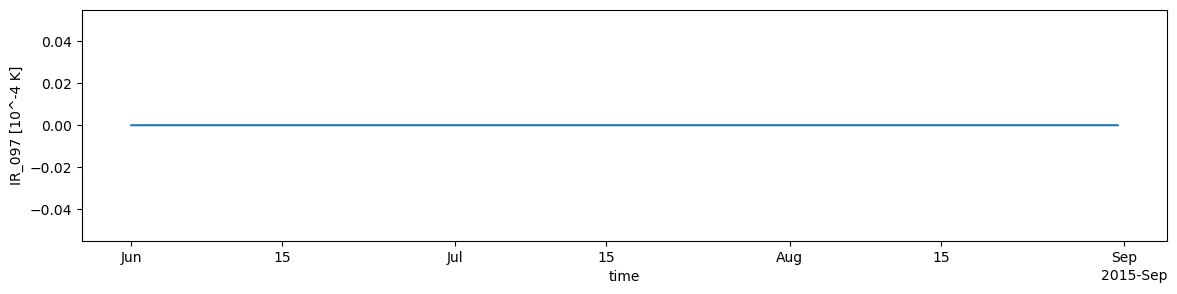

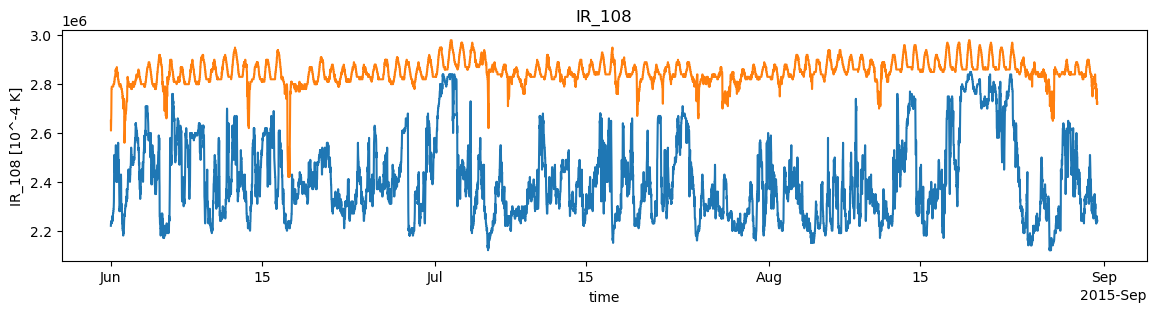

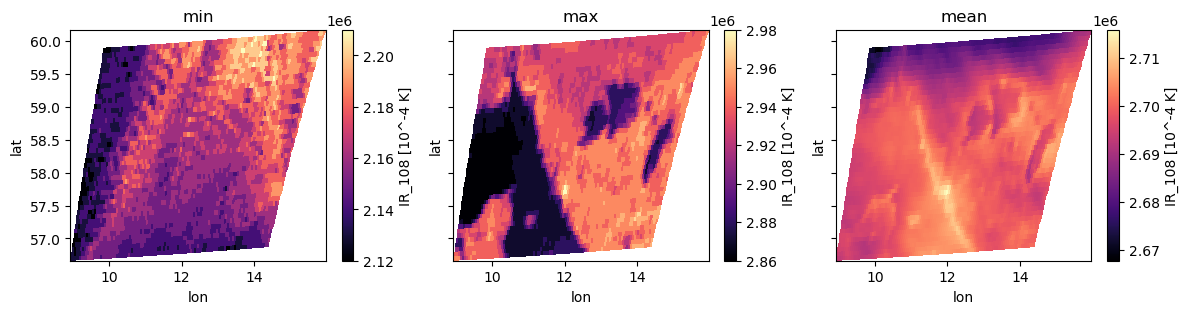

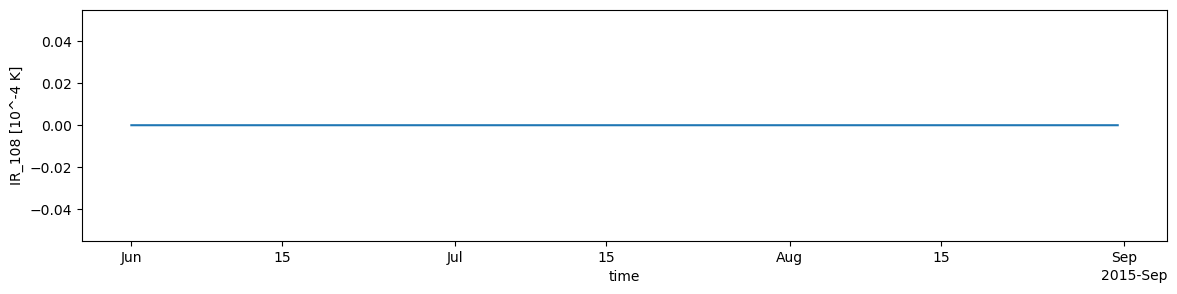

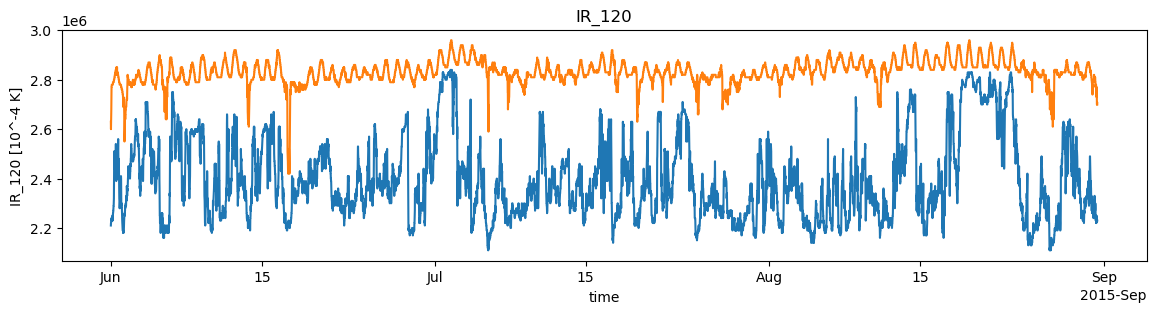

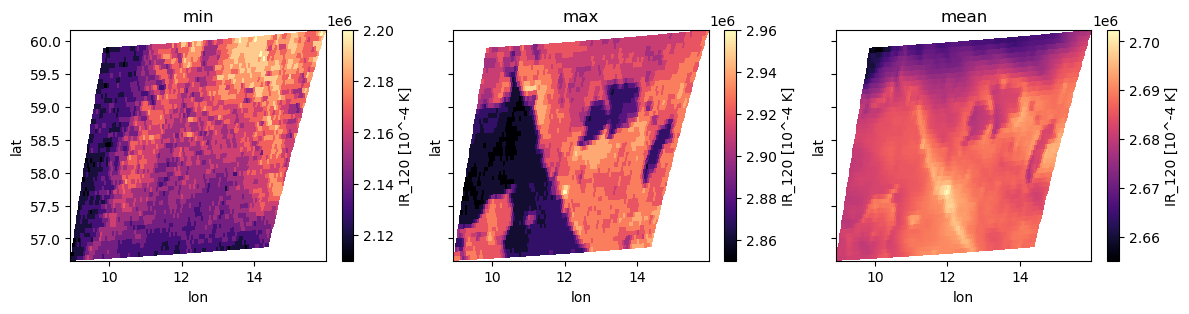

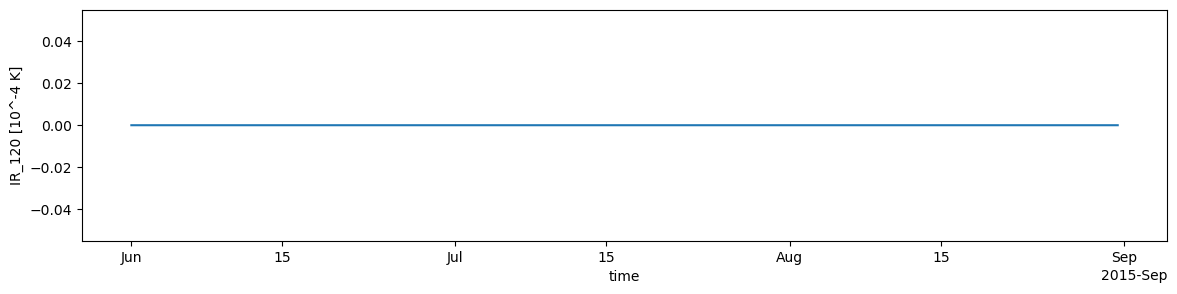

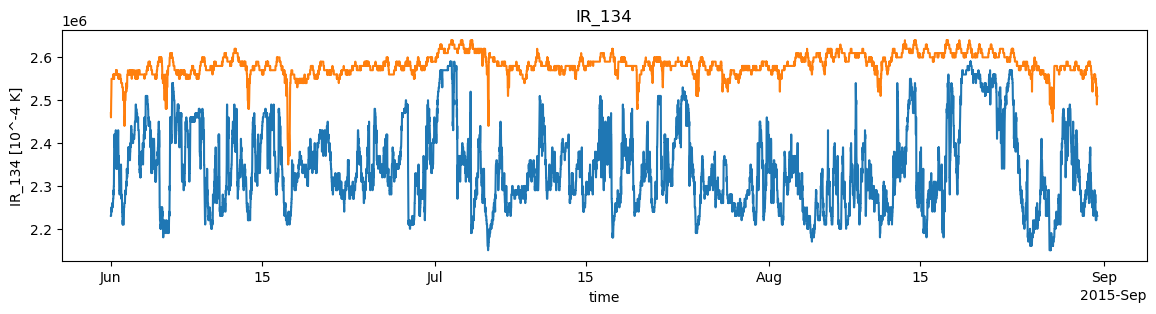

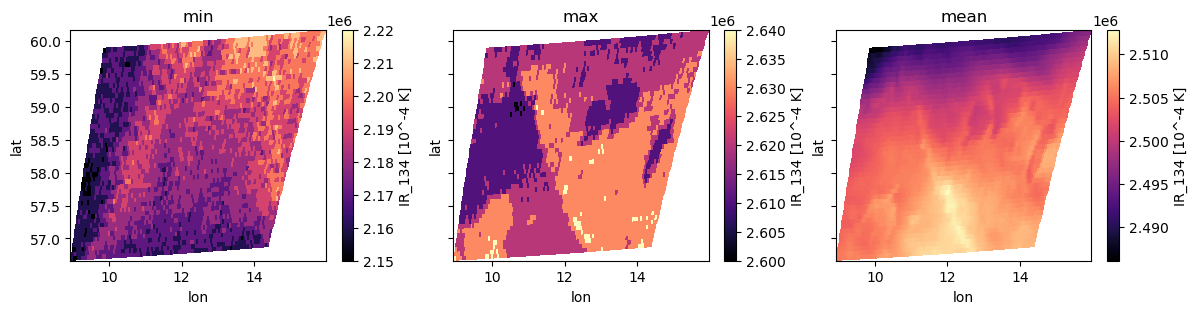

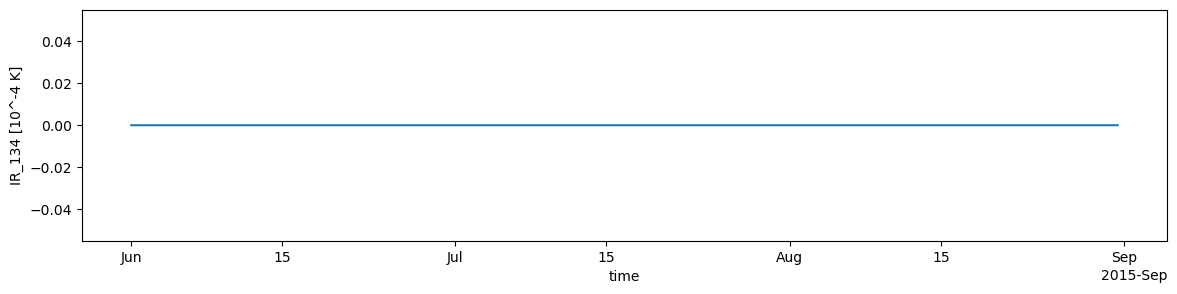

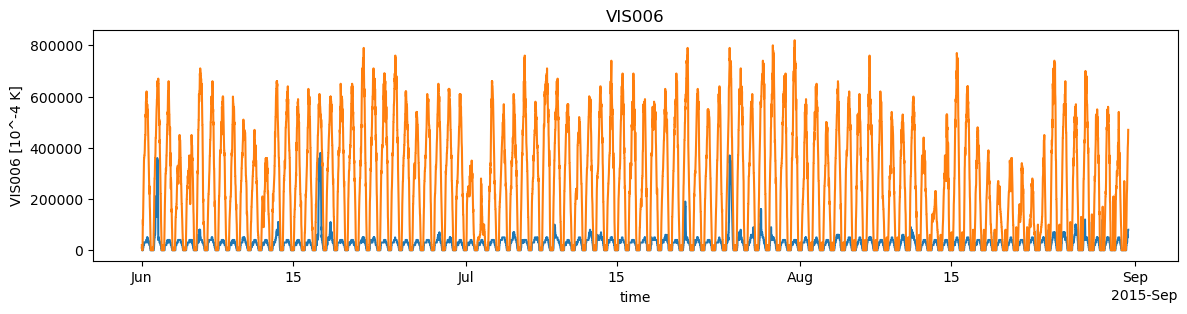

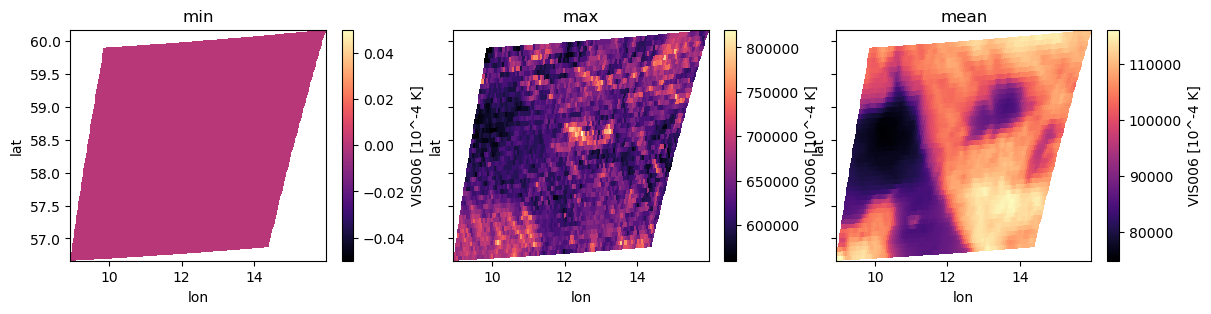

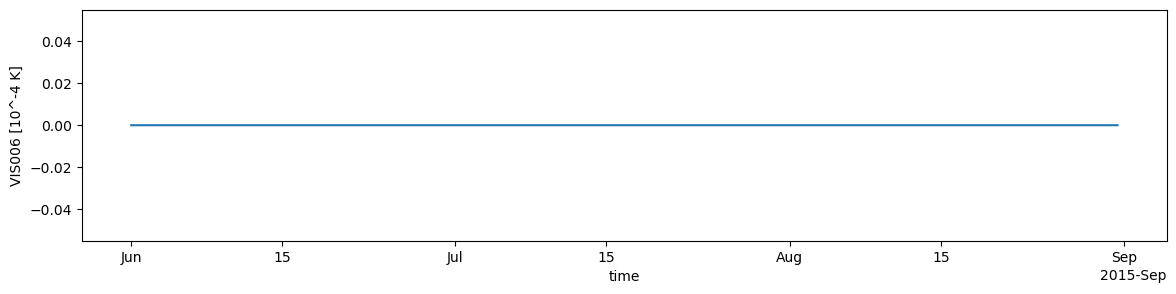

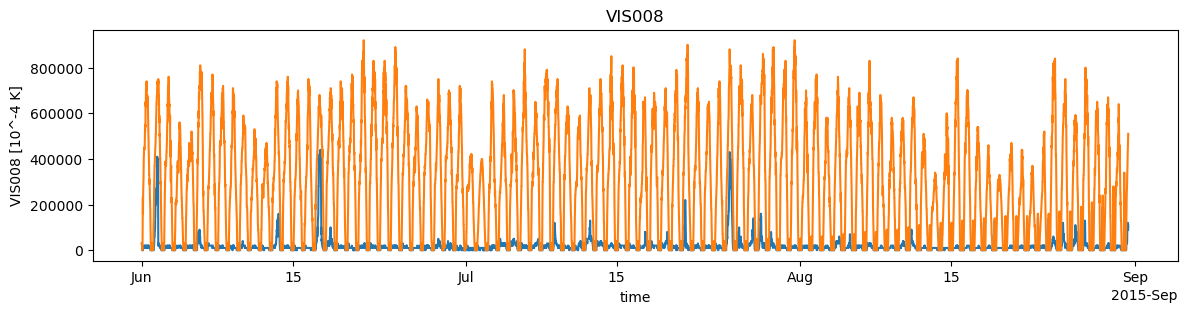

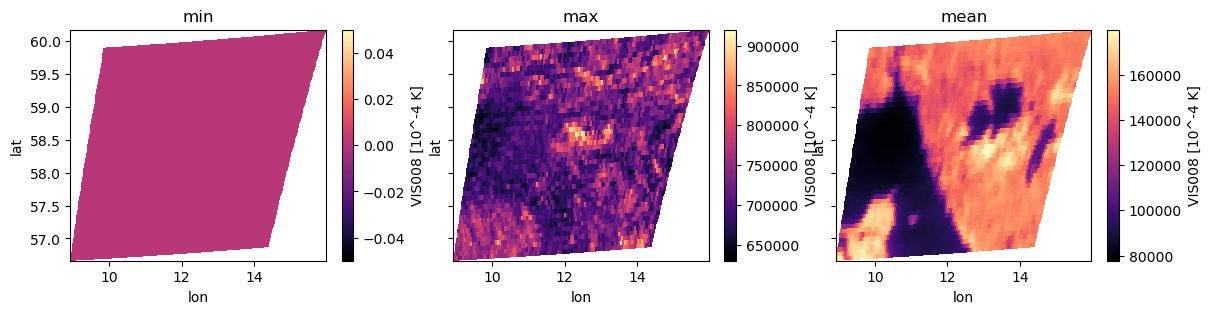

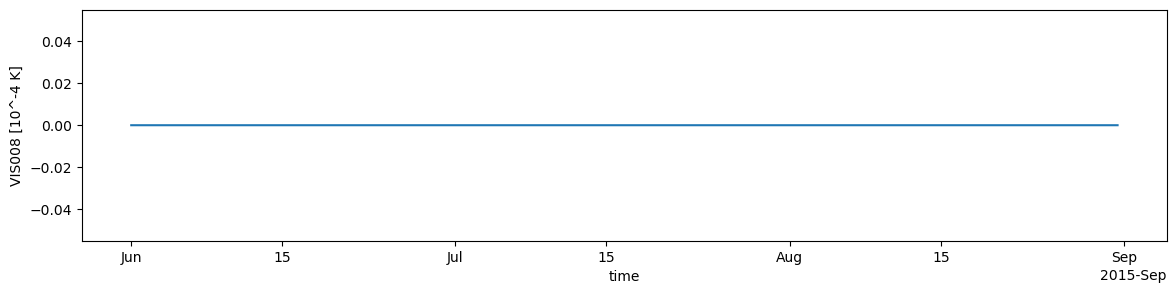

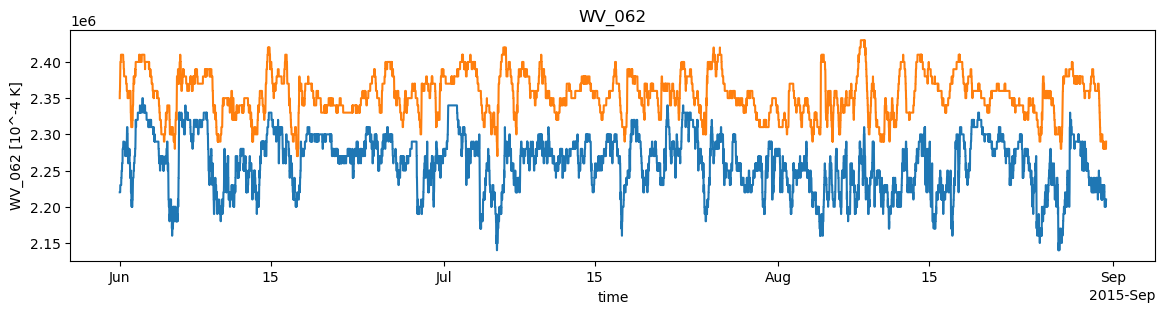

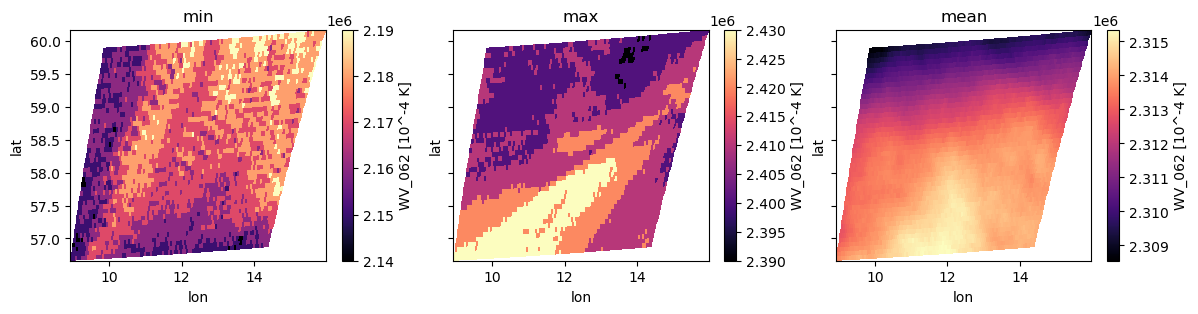

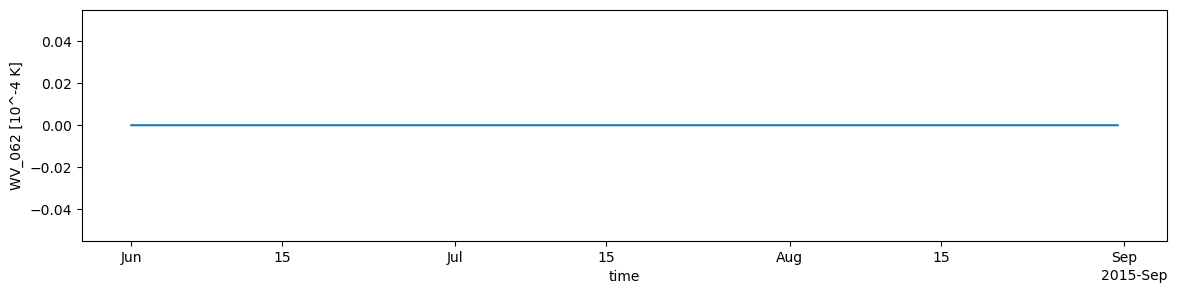

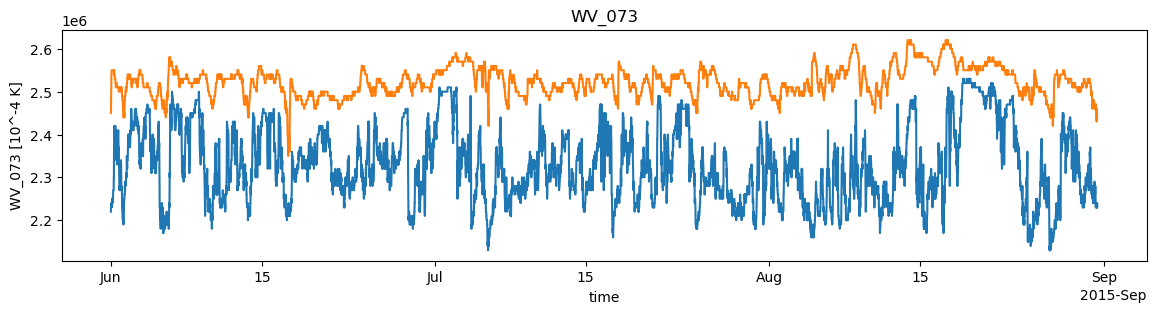

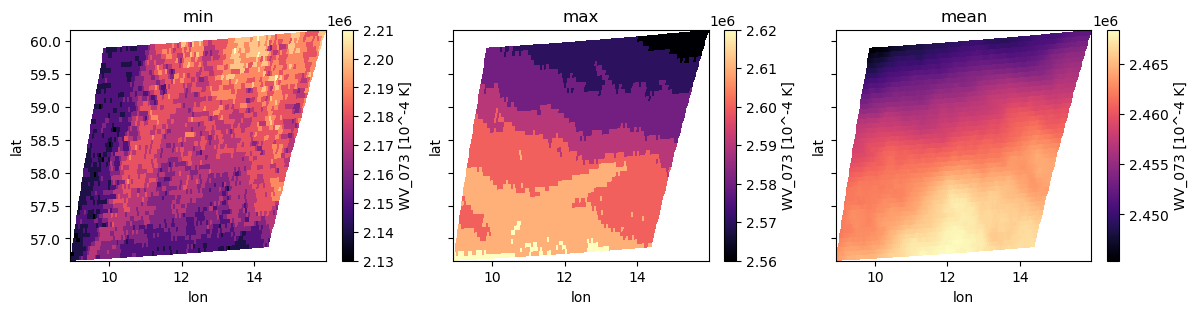

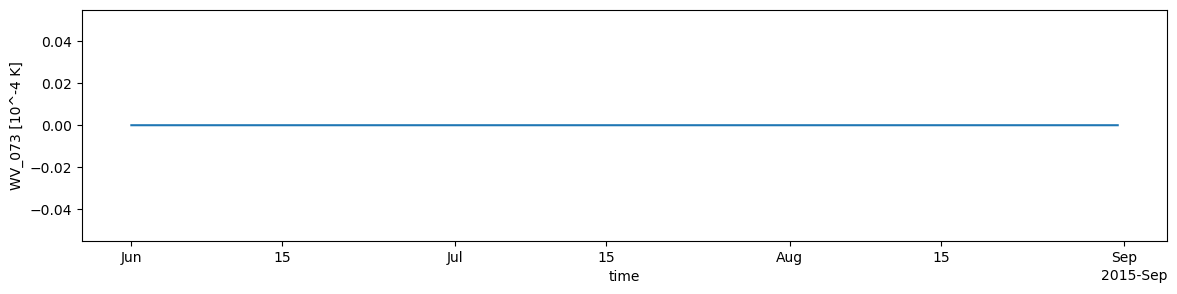

In [11]:
cmap = 'magma'

for var_name in sorted(ds_seviri.data_vars):
    fig, ax = plt.subplots(figsize=(14, 3))
    ds_seviri[var_name].min(dim=['x', 'y']).plot(ax=ax)
    ds_seviri[var_name].max(dim=['x', 'y']).plot(ax=ax)
    ax.set_title(var_name)
    fig, axs = plt.subplots(1, 3, figsize=(14, 3), sharex=True, sharey=True)
    ds_seviri[var_name].min(dim=['time']).plot(ax=axs[0], x='lon', y='lat', cmap=cmap)
    axs[0].set_title('min')
    ds_seviri[var_name].max(dim=['time']).plot(ax=axs[1], x='lon', y='lat', cmap=cmap)
    axs[1].set_title('max')
    ds_seviri[var_name].mean(dim=['time']).plot(ax=axs[2], x='lon', y='lat', cmap=cmap)
    axs[2].set_title('mean')
    fig, ax = plt.subplots(figsize=(14, 3))
    ds_seviri[var_name].isnull().sum(dim=['x', 'y']).plot(ax=ax)
    print('\n\n\n\n\n')
    plt.show()